# RL Fine-Tuning TSCP — Eksperimen 2

Fine-tune **Decoder Stage 2** (response) sebagai policy network dengan policy gradient
(Sequicity Section 4.4) di atas checkpoint supervised v2 (`tscp_supervised_v2_best.pt`).
Semua tahapan (arsitektur, RL step, training, evaluasi) ditulis eksplisit di notebook ini.

Encoder & Decoder Stage 1 dibekukan, sehingga Entity Match (dari Stage 1) diharapkan stabil
dan kenaikan terjadi pada task-completion response (Success F1).

In [2]:
import sys, os, time, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import src.preprocessing_v2 as pp

DEVICE = "cpu"
SEED = 42

def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
print("Root:", ROOT, "| Device:", DEVICE, "| Seed:", SEED)

Root: e:\coding bebas\restorant-asistent | Device: cpu | Seed: 42


## 1. Arsitektur TSCP

Sama seperti pada supervised (eksp3) — didefinisikan ulang di sini agar notebook mandiri
dan dapat memuat checkpoint supervised.

In [3]:
def combine_copy_probs(gen_logits, copy_score, source_indices, ext_size, vocab_size, src_mask=None):
    # softmax bersama atas [vocab ++ posisi source]; prob copy disebar ke index extended-vocab
    if src_mask is not None:
        copy_score = copy_score.masked_fill(~src_mask, -1e10)
    probs = F.softmax(torch.cat([gen_logits, copy_score], dim=1), dim=1)
    p_gen, p_copy = probs[:, :vocab_size], probs[:, vocab_size:]
    ext = torch.zeros((gen_logits.size(0), ext_size), device=gen_logits.device)
    ext[:, :vocab_size] = p_gen
    ext.scatter_add_(1, source_indices, p_copy)
    return torch.log(ext + 1e-12)


class Encoder(nn.Module):
    def __init__(self, vocab, embed, hidden):
        super().__init__()
        self.embedding = nn.Embedding(vocab, embed, padding_idx=0)
        self.gru = nn.GRU(embed, hidden, batch_first=True)

    def forward(self, seq, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            self.embedding(seq), lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, hidden = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return out, hidden


class Attn(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.W1 = nn.Linear(hidden, hidden, bias=False)
        self.W2 = nn.Linear(hidden, hidden, bias=False)
        self.v = nn.Linear(hidden, 1, bias=False)

    def context(self, memory, h_dec, src_mask):
        e = self.v(torch.tanh(self.W1(memory) + self.W2(h_dec).unsqueeze(1))).squeeze(2)
        if src_mask is not None:
            e = e.masked_fill(~src_mask, -1e9)
        return torch.bmm(F.softmax(e, dim=1).unsqueeze(1), memory).squeeze(1)


class DecoderStage1(nn.Module):
    def __init__(self, vocab, embed, hidden):
        super().__init__()
        self.vocab_size = vocab
        self.embedding = nn.Embedding(vocab, embed, padding_idx=0)
        self.gru = nn.GRU(embed, hidden, batch_first=True)
        self.attn = Attn(hidden)
        self.output_proj = nn.Linear(hidden * 2, vocab)
        self.W_copy = nn.Linear(hidden, hidden, bias=False)

    def step(self, dec_input, hidden, memory, src_mask=None):
        out, hidden = self.gru(self.embedding(dec_input), hidden)
        h = out.squeeze(1)
        ctx = self.attn.context(memory, h, src_mask)
        gen = self.output_proj(torch.cat([ctx, h], dim=1))
        copy = torch.bmm(torch.sigmoid(self.W_copy(memory)), h.unsqueeze(2)).squeeze(2)
        return gen, copy, hidden

    def decode(self, seq, hidden, memory, ext_source, ext_size):
        mask = ext_source != 0
        outs = []
        for t in range(seq.size(1)):
            gen, copy, hidden = self.step(seq[:, t:t + 1], hidden, memory, mask)
            outs.append(combine_copy_probs(gen, copy, ext_source, ext_size, self.vocab_size, mask))
        return torch.stack(outs, dim=1), hidden


class DecoderStage2(nn.Module):
    def __init__(self, vocab, embed, hidden, kb):
        super().__init__()
        self.vocab_size = vocab
        self.embedding = nn.Embedding(vocab, embed, padding_idx=0)
        self.gru = nn.GRU(embed + kb, hidden, batch_first=True)
        self.attn = Attn(hidden)
        self.output_proj = nn.Linear(hidden * 2, vocab)
        self.W_copy = nn.Linear(hidden, hidden, bias=False)

    def step(self, dec_input, hidden, memory, kt, src_mask=None):
        gin = torch.cat([self.embedding(dec_input), kt.unsqueeze(1)], dim=2)
        out, hidden = self.gru(gin, hidden)
        h = out.squeeze(1)
        ctx = self.attn.context(memory, h, src_mask)
        gen = self.output_proj(torch.cat([ctx, h], dim=1))
        copy = torch.bmm(torch.sigmoid(self.W_copy(memory)), h.unsqueeze(2)).squeeze(2)
        return gen, copy, hidden

    def decode(self, seq, hidden, memory, kt, ext_source, ext_size):
        mask = ext_source != 0
        outs = []
        for t in range(seq.size(1)):
            gen, copy, hidden = self.step(seq[:, t:t + 1], hidden, memory, kt, mask)
            outs.append(combine_copy_probs(gen, copy, ext_source, ext_size, self.vocab_size, mask))
        return torch.stack(outs, dim=1), hidden

In [4]:
def build_copy_map(tokens, word2idx):
    vs = len(word2idx)
    oov, oov_map, ext = [], {}, []
    for t in tokens:
        if t in word2idx:
            ext.append(word2idx[t])
        else:
            if t not in oov_map:
                oov_map[t] = vs + len(oov)
                oov.append(t)
            ext.append(oov_map[t])
    return ext, oov_map, vs + len(oov)


def target_to_ext(tokens, word2idx, oov_map):
    unk = word2idx[pp.UNK_TOKEN]
    return [word2idx[t] if t in word2idx else oov_map.get(t, unk) for t in tokens]


class TSCP(nn.Module):
    def __init__(self, vocab, embed=50, hidden=50, kb=3):
        super().__init__()
        self.vocab_size = vocab
        self.encoder = Encoder(vocab, embed, hidden)
        self.decoder1 = DecoderStage1(vocab, embed, hidden)
        self.decoder2 = DecoderStage2(vocab, embed, hidden, kb)

    @staticmethod
    def loss_fn(logp, target, ext_size):
        lp, tg = logp.reshape(-1, ext_size), target.reshape(-1)
        mask = tg.ne(0)
        nll = -lp.gather(1, tg.clamp(0, ext_size - 1).unsqueeze(1)).squeeze(1) * mask.float()
        return nll.sum() / mask.float().sum().clamp(min=1)

## 2. Evaluasi (greedy decode + metrik)

Fungsi inference & metrik (BLEU / Entity Match / Success F1), dipakai untuk memantau
val tiap epoch dan evaluasi test akhir.

In [5]:
SLOT_PH = {"address": "address_slot", "phone": "phone_slot", "postcode": "postcode_slot",
           "food": "food_slot", "area": "area_slot", "pricerange": "pricerange_slot", "name": "name_slot"}


@torch.no_grad()
def greedy(decoder, hidden, memory, src, ext_size, inv_oov, kt=None, max_len=50):
    mask = src != 0
    di = torch.tensor([[word2idx[pp.SOS_TOKEN]]], device=DEVICE)
    out = []
    for _ in range(max_len):
        if kt is None:
            gen, copy, hidden = decoder.step(di, hidden, memory, mask)
        else:
            gen, copy, hidden = decoder.step(di, hidden, memory, kt, mask)
        idx = combine_copy_probs(gen, copy, src, ext_size, VOCAB, mask).argmax(1).item()
        if idx == word2idx[pp.EOS_TOKEN]:
            break
        out.append(idx2word[idx] if idx < VOCAB else inv_oov.get(idx, pp.UNK_TOKEN))
        di = torch.tensor([[idx if idx < VOCAB else word2idx[pp.UNK_TOKEN]]], device=DEVICE)
    return out


@torch.no_grad()
def generate(model, sample):
    model.eval()
    it = pp.tokenize(sample["input"])
    ids = torch.tensor([pp.tokens_to_ids(it, word2idx)], device=DEVICE)
    enc_out, enc_h = model.encoder(ids, torch.tensor([len(it)]))
    ext, omap, esz = build_copy_map(it, word2idx)
    pb = greedy(model.decoder1, enc_h, enc_out, torch.tensor([ext], device=DEVICE), esz,
                {v: k for k, v in omap.items()})
    pb_text = " ".join(pb)
    bspan_tokens = [pp.SOS_TOKEN] + pb
    bids = torch.tensor([pp.tokens_to_ids(bspan_tokens, word2idx)], device=DEVICE)
    bspan_out, bspan_h = model.decoder1.gru(model.decoder1.embedding(bids), enc_h)
    bext, bomap, besz = build_copy_map(bspan_tokens, word2idx)
    kt = pp.get_kt_from_bspan(pb_text, database).unsqueeze(0).to(DEVICE)
    pr = greedy(model.decoder2, bspan_h, bspan_out, torch.tensor([bext], device=DEVICE), besz,
                {v: k for k, v in bomap.items()}, kt=kt)
    return pb_text, " ".join(pr)


def entity_match(pred_b, gold_b):
    ok = sum(set(v.lower() for v in pp.parse_bspan(p)[0]) == set(v.lower() for v in pp.parse_bspan(g)[0])
             for p, g in zip(pred_b, gold_b))
    return ok / max(len(gold_b), 1)


def success_f1(pred_r, gold_b):
    precs, recs = [], []
    for resp, g in zip(pred_r, gold_b):
        expected = {SLOT_PH[r.lower()] for r in pp.parse_bspan(g)[1] if r.lower() in SLOT_PH}
        if not expected:
            continue
        low = resp.lower()
        found = {p for p in expected if p in low}
        present = {p for p in SLOT_PH.values() if p in low}
        recs.append(len(found) / len(expected))
        precs.append(len(found & present) / len(present) if present else 0.0)
    if not precs:
        return 0.0
    P, R = sum(precs) / len(precs), sum(recs) / len(recs)
    return 2 * P * R / (P + R) if P + R else 0.0


def evaluate(model, samples):
    pred_b, gold_b, pred_r, refs, hyps = [], [], [], [], []
    for s in samples:
        pb, pr = generate(model, s)
        pred_b.append(pb); gold_b.append(s["target_bspan"]); pred_r.append(pr)
        refs.append([pp.tokenize(s["target_response"])]); hyps.append(pp.tokenize(pr))
    pairs = [(r, h) for r, h in zip(refs, hyps) if h]
    bleu = corpus_bleu([r for r, _ in pairs], [h for _, h in pairs],
                       smoothing_function=SmoothingFunction().method1) if pairs else 0.0
    return {"BLEU": bleu, "EntityMatch": entity_match(pred_b, gold_b), "SuccessF1": success_f1(pred_r, gold_b)}

## 3. Konfigurasi & Muat Model

Hyperparameter RL (paper Section 5.2): lr 1e-4, decay lambda 0.8. Reward +1 saat placeholder
slot yang diminta muncul, -0.1 selain itu. `RL_ALPHA` = bobot supervised anchor untuk mencegah
catastrophic forgetting. Data: **train / val / test**. Encoder & Decoder1 dibekukan.

In [6]:
RL_LR, RL_LAMBDA, RL_EPOCHS = 1e-4, 0.8, 15
REWARD_POS, REWARD_NEG, RL_ALPHA = 1.0, -0.1, 0.5
MAX_DECODE, VAL_EVAL_N, CLIP = 50, 150, 5.0
SUP_CKPT = ROOT / "checkpoints" / "tscp_supervised_v2_best.pt"
RL_CKPT = ROOT / "checkpoints" / "tscp_rl_v2_best.pt"

data = pp.prepare_data()
word2idx, idx2word, database = data["word2idx"], data["idx2word"], data["database"]
VOCAB = len(word2idx)
REQ_MAP = pp.DB_FIELD_TO_SLOT  # 'phone' -> 'PHONE_SLOT'

ckpt = torch.load(SUP_CKPT, map_location=DEVICE, weights_only=False)
model = TSCP(VOCAB).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

for p in model.encoder.parameters():
    p.requires_grad = False
for p in model.decoder1.parameters():
    p.requires_grad = False
opt = torch.optim.Adam(model.decoder2.parameters(), lr=RL_LR)

rl_samples = [s for s in data["train"] if pp.parse_bspan(s["target_bspan"])[1]]
val_eval = data["val"][:VAL_EVAL_N]
print(f"Supervised ckpt epoch {ckpt['epoch']}")
print(f"Train samples dengan request slot: {len(rl_samples)} / {len(data['train'])}")

Dialog -> train 405 | val 135 | test 136
Sample -> train 1635 | val 553 | test 556
Vocab  -> 613 (min_freq=2, max=800)
Supervised ckpt epoch 15
Train samples dengan request slot: 480 / 1635


## 4. RL Step

Untuk tiap sample: encode + belief span gold (Decoder1 beku) -> sampling response dari
Decoder2 (policy) sambil mencatat log-prob. Reward per token -> discounted return
(dinormalisasi sebagai baseline) -> policy gradient (Eq. 11). Ditambah supervised anchor.

In [7]:
def rl_step(sample):
    it = pp.tokenize(sample["input"])
    ids = torch.tensor([pp.tokens_to_ids(it, word2idx)], device=DEVICE)
    bspan_tokens = [pp.SOS_TOKEN] + pp.tokenize(sample["target_bspan"])
    with torch.no_grad():
        _, enc_h = model.encoder(ids, torch.tensor([len(it)]))
        bids = torch.tensor([pp.tokens_to_ids(bspan_tokens, word2idx)], device=DEVICE)
        bspan_out, bspan_h = model.decoder1.gru(model.decoder1.embedding(bids), enc_h)

    bext, bomap, besz = build_copy_map(bspan_tokens, word2idx)
    inv = {v: k for k, v in bomap.items()}
    bsrc = torch.tensor([bext], device=DEVICE)
    mask = bsrc != 0
    kt = pp.get_kt_from_bspan(sample["target_bspan"], database).unsqueeze(0).to(DEVICE)
    req_ph = {REQ_MAP[r.lower()] for r in pp.parse_bspan(sample["target_bspan"])[1] if r.lower() in REQ_MAP}

    di = torch.tensor([[word2idx[pp.SOS_TOKEN]]], device=DEVICE)
    hidden = bspan_h
    logps, rewards = [], []
    for _ in range(MAX_DECODE):
        gen, copy, hidden = model.decoder2.step(di, hidden, bspan_out, kt, mask)
        logp = combine_copy_probs(gen, copy, bsrc, besz, VOCAB, mask)
        idx = torch.multinomial(logp.exp(), 1).item()
        logps.append(logp[0, idx])
        tok = idx2word[idx] if idx < VOCAB else inv.get(idx, pp.UNK_TOKEN)
        rewards.append(REWARD_POS if (idx < VOCAB and tok in req_ph) else REWARD_NEG)
        if idx == word2idx[pp.EOS_TOKEN]:
            break
        di = torch.tensor([[idx if idx < VOCAB else word2idx[pp.UNK_TOKEN]]], device=DEVICE)

    returns, acc = [], 0.0
    for r in reversed(rewards):
        acc = r + RL_LAMBDA * acc
        returns.insert(0, acc)
    returns = torch.tensor(returns, device=DEVICE)
    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    policy_loss = -(returns * torch.stack(logps)).mean()

    rt = [pp.SOS_TOKEN] + pp.tokenize(sample["target_response"]) + [pp.EOS_TOKEN]
    resp_in = torch.tensor([pp.tokens_to_ids(rt[:-1], word2idx)], device=DEVICE)
    resp_logp, _ = model.decoder2.decode(resp_in, bspan_h, bspan_out, kt, bsrc, besz)
    resp_tgt = torch.tensor([target_to_ext(rt[1:], word2idx, bomap)], device=DEVICE)
    anchor = TSCP.loss_fn(resp_logp, resp_tgt, besz)

    return policy_loss + RL_ALPHA * anchor, sum(rewards) / len(rewards)

## 5. Training Loop

Update per-sample (REINFORCE). Tiap epoch menampilkan **avg reward + metrik val**
(BLEU / Entity Match / Success F1). Checkpoint dipilih berdasar **val Success-F1**
(target RL). Baseline supervised (sebelum RL) dihitung sebagai pembanding.

In [8]:
base = evaluate(model, val_eval)
print(f"Baseline supervised (val) -> BLEU {base['BLEU']:.4f} | EM {base['EntityMatch']:.4f} | F1 {base['SuccessF1']:.4f}")

set_seed(SEED)
hist = {"reward": [], "loss": [], "bleu": [], "em": [], "f1": []}
best_f1 = base["SuccessF1"]
for epoch in range(1, RL_EPOCHS + 1):
    model.train()
    random.shuffle(rl_samples)
    t0 = time.time()
    tot_loss = tot_rew = 0.0
    for s in rl_samples:
        loss, avg_r = rl_step(s)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.decoder2.parameters(), CLIP)
        opt.step()
        tot_loss += loss.item(); tot_rew += avg_r
    m = evaluate(model, val_eval)
    hist["reward"].append(tot_rew / len(rl_samples)); hist["loss"].append(tot_loss / len(rl_samples))
    hist["bleu"].append(m["BLEU"]); hist["em"].append(m["EntityMatch"]); hist["f1"].append(m["SuccessF1"])
    print(f"Epoch {epoch:2d} | reward {tot_rew/len(rl_samples):+.4f} | loss {tot_loss/len(rl_samples):.4f} | "
          f"val BLEU {m['BLEU']:.4f} | EM {m['EntityMatch']:.4f} | F1 {m['SuccessF1']:.4f} | {time.time()-t0:.1f}s")
    if m["SuccessF1"] > best_f1:
        best_f1 = m["SuccessF1"]
        torch.save({"model_state_dict": model.state_dict(), "word2idx": word2idx,
                    "vocab_size": VOCAB, "epoch": epoch, "val_success_f1": best_f1}, RL_CKPT)
        print(f"  saved (val F1 {best_f1:.4f})")
print("Best val F1:", round(best_f1, 4))

Baseline supervised (val) -> BLEU 0.2117 | EM 0.9333 | F1 0.6480
Epoch  1 | reward +0.0106 | loss 0.1522 | val BLEU 0.2035 | EM 0.9333 | F1 0.6757 | 25.0s
  saved (val F1 0.6757)
Epoch  2 | reward +0.0197 | loss 0.0948 | val BLEU 0.1787 | EM 0.9333 | F1 0.8696 | 23.6s
  saved (val F1 0.8696)
Epoch  3 | reward +0.0413 | loss 0.1408 | val BLEU 0.1523 | EM 0.9333 | F1 0.8675 | 23.7s
Epoch  4 | reward +0.0760 | loss 0.1273 | val BLEU 0.1706 | EM 0.9333 | F1 0.9573 | 24.2s
  saved (val F1 0.9573)
Epoch  5 | reward +0.1278 | loss 0.1566 | val BLEU 0.1078 | EM 0.9333 | F1 0.8372 | 27.1s
Epoch  6 | reward +0.1900 | loss 0.1005 | val BLEU 0.1005 | EM 0.9333 | F1 0.8516 | 30.2s
Epoch  7 | reward +0.3850 | loss 0.1608 | val BLEU 0.0984 | EM 0.9333 | F1 0.8516 | 35.5s
Epoch  8 | reward +0.4753 | loss 0.2021 | val BLEU 0.1080 | EM 0.9333 | F1 0.8338 | 35.4s
Epoch  9 | reward +0.4522 | loss 0.1610 | val BLEU 0.0998 | EM 0.9333 | F1 0.8622 | 78.5s
Epoch 10 | reward +0.4523 | loss 0.1852 | val BLEU 0.

## 6. Visualisasi & Justifikasi RL

Kiri: **avg reward per epoch** — bukti policy belajar (reward naik = makin sering men-decode
slot yang diminta). Kanan: metrik val vs **garis putus-putus baseline supervised** —
memperlihatkan Success F1 terangkat di atas baseline, sedang Entity Match tetap (Stage 1 beku).

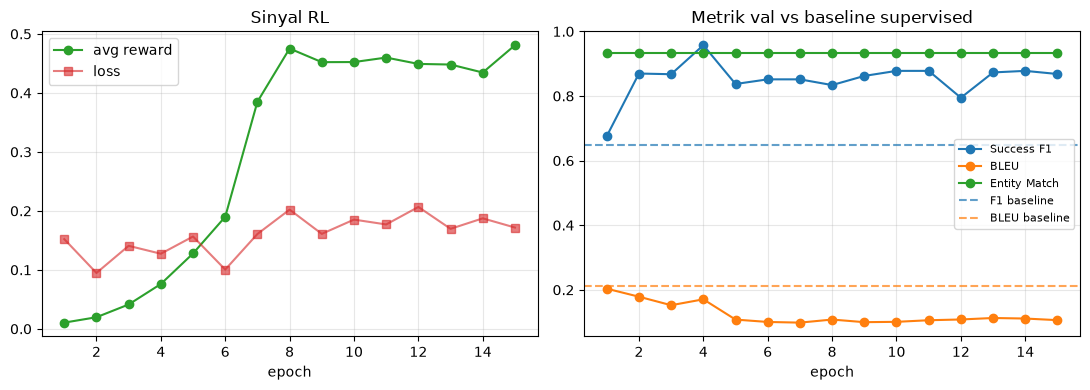

In [9]:
ep = range(1, len(hist["reward"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, hist["reward"], marker="o", color="tab:green", label="avg reward")
ax[0].plot(ep, hist["loss"], marker="s", color="tab:red", alpha=0.6, label="loss")
ax[0].set_title("Sinyal RL"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, hist["f1"], marker="o", label="Success F1")
ax[1].plot(ep, hist["bleu"], marker="o", label="BLEU")
ax[1].plot(ep, hist["em"], marker="o", label="Entity Match")
ax[1].axhline(base["SuccessF1"], ls="--", color="tab:blue", alpha=0.7, label="F1 baseline")
ax[1].axhline(base["BLEU"], ls="--", color="tab:orange", alpha=0.7, label="BLEU baseline")
ax[1].set_title("Metrik val vs baseline supervised"); ax[1].set_xlabel("epoch")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Evaluasi Test: Supervised vs RL

Muat checkpoint RL terbaik, evaluasi **test set**, bandingkan dengan supervised (kolom Delta).

In [10]:
sup = TSCP(VOCAB).to(DEVICE)
sup.load_state_dict(ckpt["model_state_dict"])
sup_res = evaluate(sup, data["test"])

best = torch.load(RL_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(best["model_state_dict"])
rl_res = evaluate(model, data["test"])

print(f"{'Metrik':<14}{'Supervised':>12}{'RL':>12}{'Delta':>10}")
for k in ("BLEU", "EntityMatch", "SuccessF1"):
    d = rl_res[k] - sup_res[k]
    print(f"{k:<14}{sup_res[k]:>12.4f}{rl_res[k]:>12.4f}{d:>+10.4f}")

Metrik          Supervised          RL     Delta
BLEU                0.2181      0.1746   -0.0435
EntityMatch         0.9245      0.9245   +0.0000
SuccessF1           0.6319      0.8993   +0.2674


## 8. Catatan

`tscp_rl_v2_best.pt` menyimpan `word2idx`. RL hanya mengubah Decoder Stage 2 -> Entity Match
stabil, Success F1 naik. BLEU cenderung turun (reward mengejar task-completion, bukan
kemiripan n-gram) — trade-off wajar, ditahan oleh supervised anchor. Konvensi `<Inf>`/613.